## [HW] due: 250510 6pm
- 제출: slcf.snu@gmail.com
- 다운방법: 파일 > 다운로드 > .ipynb 다운로드
- 파일명: KBI_이름_TS_forecasting.ipynb
- data (일별 전기 사용량): https://github.com/safeai-snu/Econometrics/blob/main/dataset/Ch.4/vic_elec.csv (아래 전처리 코드 그대로 사용하시면 됩니다)
- 실습 파일의 코드를 위 데이터셋으로 바꾸어 재실행 후 제출
- Horizon, Seasonality 자유 설정

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

vic_elec = pd.read_csv("https://raw.githubusercontent.com/safeai-snu/Econometrics/main/dataset/Ch.4/vic_elec.csv")

vic_elec['Time'] = pd.to_datetime(vic_elec['Time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
vic_elec['Date'] = vic_elec['Time'].dt.date

vic_elec = vic_elec[(pd.to_datetime(vic_elec['Date']).dt.year == 2013) | (pd.to_datetime(vic_elec['Date']).dt.year == 2014)]

#일별 데이터로의 전처리
vic_elec_daily = vic_elec.groupby('Date').agg({
    'Demand': lambda x: x.sum() / 1e3,
    'Temperature': 'max',
    'Holiday': 'any'
}).reset_index()

vic_elec_daily['Day_Type'] = np.where(
    vic_elec_daily['Holiday'], 'Holiday',
    np.where(pd.to_datetime(vic_elec_daily['Date']).dt.weekday.isin([0, 1, 2, 3, 4]), 'Weekday', 'Weekend')
)

vic_elec_daily.index = vic_elec_daily['Date'].values
df = vic_elec_daily[['Demand']]
df

,Demand
2013-01-01,171.851616
2013-01-02,191.764426
2013-01-03,238.838952
2013-01-04,289.615144
2013-01-05,214.877391
...,...
2014-12-27,169.722866
2014-12-28,184.147362
2014-12-29,187.414815
2014-12-30,182.106744


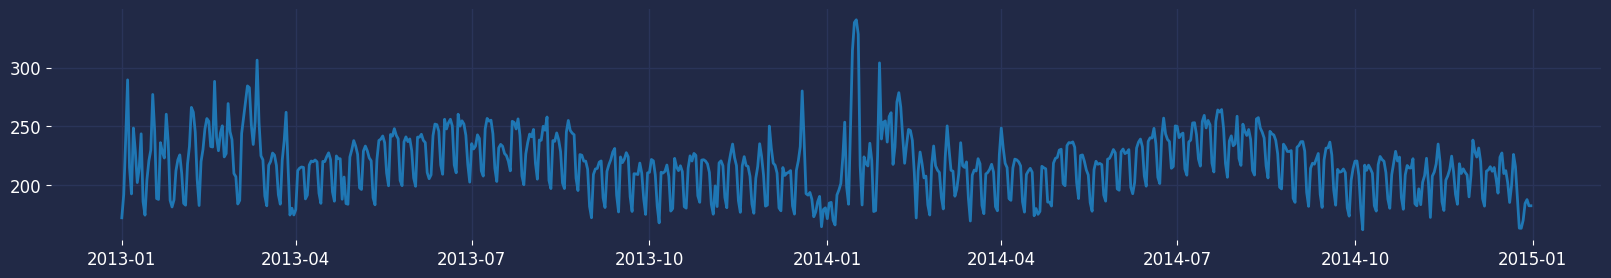

In [118]:
plt.figure(figsize=(20,3))
plt.plot(df['Demand'])

### Todo: 위의 df 를 아래 df 형식 (column: ds, y, unique_id) 로 바꿔주세요.


In [ ]:
horizon = 12

# put code here !!!


In [146]:
# check (df 출력시 아래와 같이 나와야 함)
df

,ds,y,unique_id
0,2013-01-01,171.851616,elec
1,2013-01-02,191.764426,elec
2,2013-01-03,238.838952,elec
3,2013-01-04,289.615144,elec
4,2013-01-05,214.877391,elec
...,...,...,...
725,2014-12-27,169.722866,elec
726,2014-12-28,184.147362,elec
727,2014-12-29,187.414815,elec
728,2014-12-30,182.106744,elec


In [120]:
Y_train_df = df[:-horizon]
Y_test_df = df[-horizon:]

## DL forecasting in time series
- NeuralForecast: https://nixtlaverse.nixtla.io/neuralforecast/docs/capabilities/overview.html

In [121]:
!pip install -q neuralforecast utilsforecast
!pip show neuralforecast

from neuralforecast import NeuralForecast
from neuralforecast.models import MLP
from neuralforecast.losses.pytorch import MAE
from neuralforecast.tsdataset import TimeSeriesDataset

import pytorch_lightning as pl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Name: neuralforecast
Version: 3.0.0
Summary: Time series forecasting suite using deep learning models
Home-page: https://github.com/Nixtla/neuralforecast/
Author: Nixtla
Author-email: business@nixtla.io
License: Apache Software License 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: coreforecast, fsspec, numpy, optuna, pandas, pytorch-lightning, ray, torch, utilsforecast
Required-by: 


### Training Forecasting Models

In [122]:
from neuralforecast.models import NBEATS, NHITS, PatchTST
#from neuralforecast.models import DLinear, Autoforemr, Informer, DeepAR, iTransformer

horizon = 12

models = [
    NBEATS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    NHITS(h=horizon, input_size=2*horizon, loss=MAE(), max_steps=300),
    PatchTST(h=horizon,
            input_size=2*horizon,
            patch_len=2*horizon,
            stride=2*horizon,
            revin=False,
            hidden_size=16,
            n_heads=4,
            scaler_type='robust',
            loss=MAE(),
            learning_rate=1e-3,
            max_steps=300,
            val_check_steps=50,
            early_stop_patience_steps=2)
]

nf = NeuralForecast(models=models, freq='D')
nf.fit(df=Y_train_df, val_size=horizon)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.4 M  | train
-------------------------------------------------------
2.4 M     Trainable params
900       Non-trainable params
2.4 M     Total params
9.789     Total estimated mo

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [123]:
forecasts = nf.predict(futr_df=Y_test_df)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

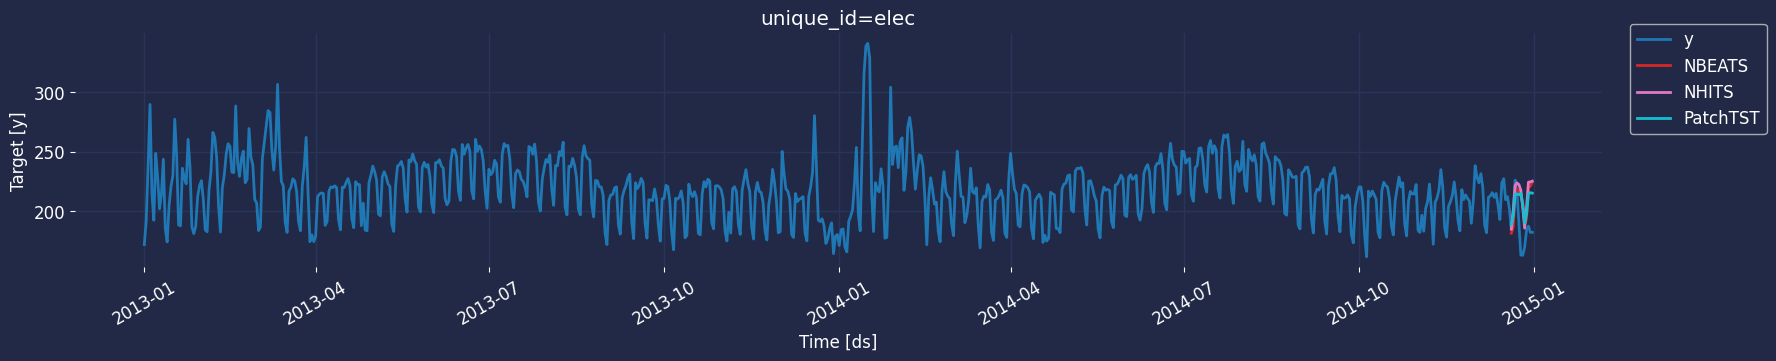

In [124]:
from utilsforecast.plotting import plot_series

plot_series(df, forecasts)

In [125]:
from sklearn.metrics import mean_absolute_error

mae_scores = {}

for uid in forecasts['unique_id'].unique():
    mae_scores[uid] = {}
    y_true = Y_test_df[Y_test_df['unique_id'] == uid]['y'].values

    for col in forecasts.columns:
        if col in ['ds', 'unique_id'] or col.endswith('lo-95') or col.endswith('hi-95'):
            continue

        y_pred = forecasts[forecasts['unique_id'] == uid][col].values
        y_pred = y_pred[:len(y_true)]  # 길이 맞추기 (예방적)
        mae = mean_absolute_error(y_true, y_pred)
        mae_scores[uid][col] = mae

print("MAE Scores (by series and model):")
for uid, model_dict in mae_scores.items():
    print(f"\n{uid}:")
    for model, score in model_dict.items():
        print(f"  {model}: {score:.3f}")

MAE Scores (by series and model):

elec:
  NBEATS: 24.221
  NHITS: 24.886
  PatchTST: 22.249


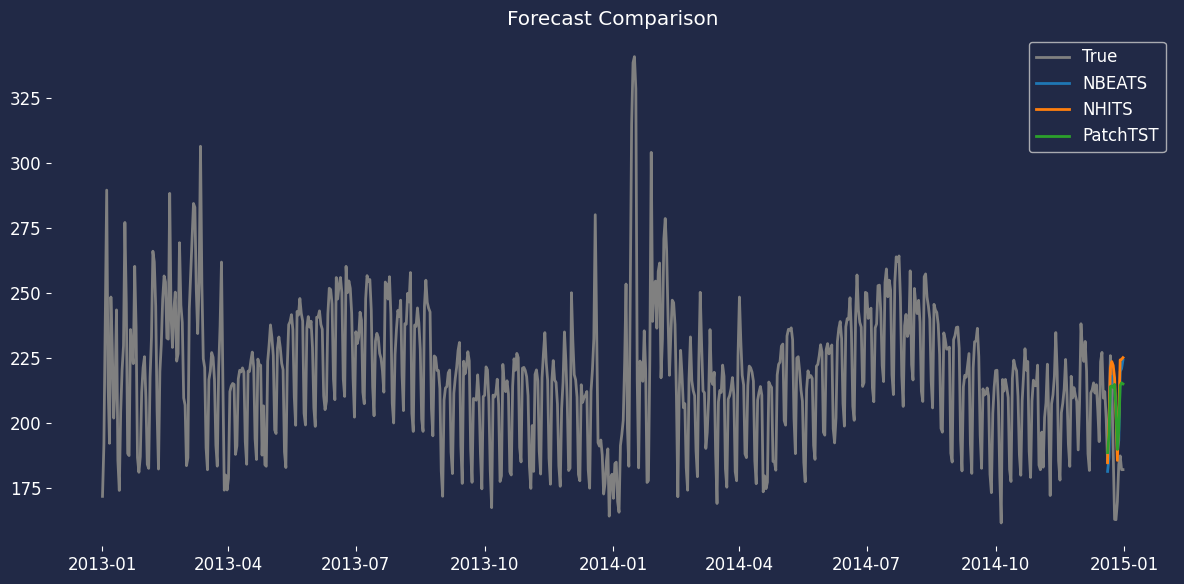

In [126]:
Y_hat_df = forecasts.reset_index(drop=True).drop(columns=['unique_id','ds'])
plot_df_nf = pd.concat([Y_test_df.reset_index(drop=True), Y_hat_df], axis=1)
plot_df = pd.concat([Y_train_df, plot_df_nf])

plot_df = plot_df[plot_df['unique_id'] == 'elec']

plt.figure(figsize=(12, 6))
plt.plot(plot_df['ds'], plot_df['y'], label='True', c='grey')

for col in forecasts.columns:
    if 'median' in col or col.startswith('ds') or col.startswith('unique_id'):
        continue
    if 'PatchTST' in col and '-lo-' in col:
        continue  # Skip low/high intervals for now
    plt.plot(plot_df['ds'], plot_df[col], label=col)

plt.legend()
plt.title("Forecast Comparison")
plt.grid()
plt.tight_layout()
plt.show()

## StatsForecast

In [127]:
!pip install statsforecast

In [128]:
import matplotlib.pyplot as plt

dark_style = {
    'figure.facecolor': '#212946',
    'axes.facecolor': '#212946',
    'savefig.facecolor': '#212946',
    'axes.grid': True,
    'axes.grid.which': 'both',
    'grid.color': '#2A3459',
    'grid.linewidth': 1,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'text.color': '#FFFFFF',
    'axes.labelcolor': '#FFFFFF',
    'xtick.color': '#FFFFFF',
    'ytick.color': '#FFFFFF',
    'font.size': 12,
    'lines.linewidth': 2
}
plt.rcParams.update(dark_style)

from pylab import rcParams
rcParams['figure.figsize'] = (18,7)

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

###  AutoARIMA, AutoETS, AutoTheta with StatsForecast

In [129]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS, AutoTheta
from statsforecast.arima import arima_string

In [130]:
horizon = 12
season_length = 4

models = [AutoARIMA(season_length=season_length),
          AutoETS(model='ZZZ', season_length=season_length),
          AutoTheta(season_length=season_length,
                     decomposition_type="additive",
                     model="STM")]

In [131]:
sf = StatsForecast(models=models, freq='D')
sf.fit(df=Y_train_df)

StatsForecast(models=[AutoARIMA,AutoETS,AutoTheta])

## Forecasting results

In [132]:
Y_train_df = Y_train_df[['unique_id', 'ds', 'y']]
Y_test_df = Y_test_df[['unique_id', 'ds', 'y']]

In [133]:
Y_hat_df = sf.forecast(df=Y_train_df, h=horizon, fitted=True)

In [134]:
Y_hat_df

,unique_id,ds,AutoARIMA,AutoETS,AutoTheta
0,elec,2014-12-20,185.379839,201.82146,201.916192
1,elec,2014-12-21,188.109827,201.82146,201.909238
2,elec,2014-12-22,209.926781,201.82146,201.902284
3,elec,2014-12-23,212.425063,201.82146,201.895329
4,elec,2014-12-24,205.996581,201.82146,201.888375
5,elec,2014-12-25,206.262291,201.82146,201.881421
6,elec,2014-12-26,201.687566,201.82146,201.874466
7,elec,2014-12-27,187.733359,201.82146,201.867512
8,elec,2014-12-28,193.803283,201.82146,201.860557
9,elec,2014-12-29,211.444439,201.82146,201.853603


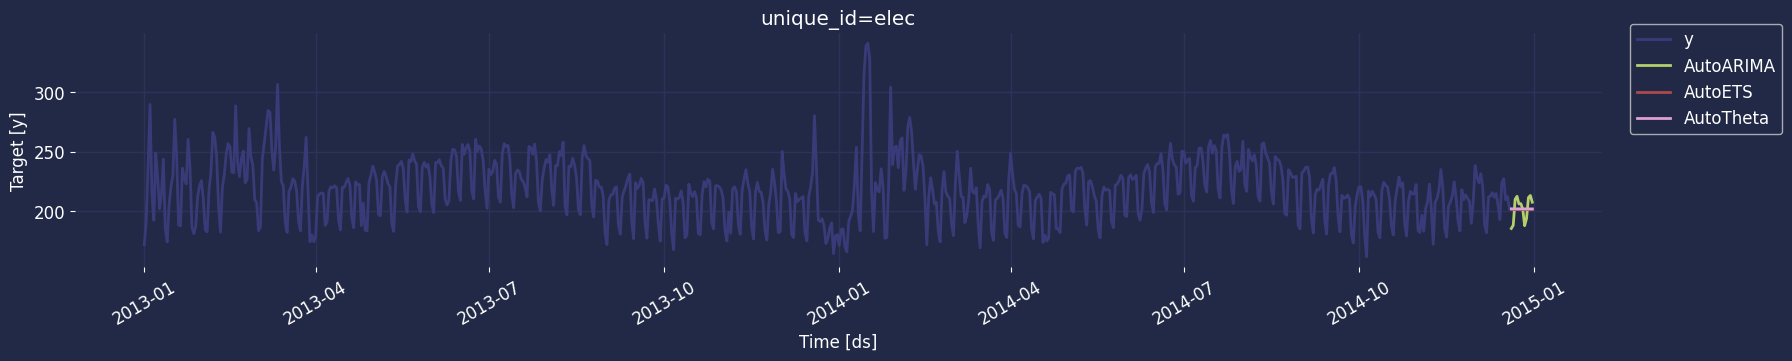

In [135]:
sf.plot(Y_train_df, Y_hat_df)

In [136]:
# values=sf.forecast_fitted_values()
# values

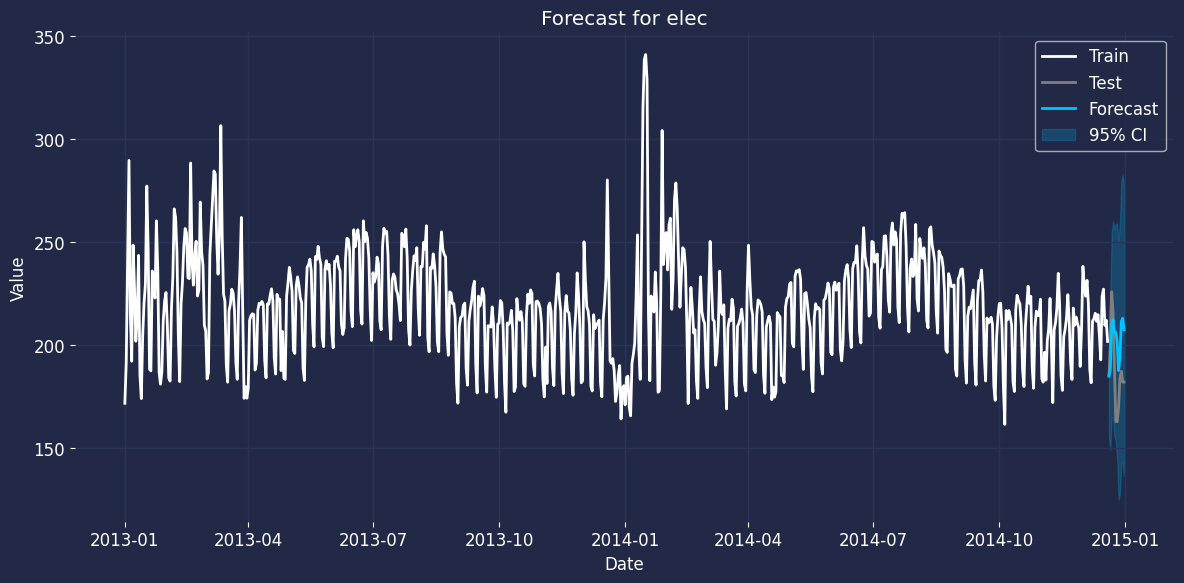

In [137]:
forecasts = sf.forecast(df=Y_train_df, h=horizon, level=[95])

uid = 'elec'
fcst = forecasts[forecasts['unique_id'] == uid]

# 실제값
y_train = Y_train_df[Y_train_df['unique_id'] == uid]
y_test = Y_test_df[Y_test_df['unique_id'] == uid]

plt.figure(figsize=(12, 6))

plt.plot(y_train['ds'], y_train['y'], label='Train', color='white')
plt.plot(y_test['ds'], y_test['y'], label='Test', color='gray')

# 예측값 (예: AutoARIMA)
plt.plot(fcst['ds'], fcst['AutoARIMA'], label='Forecast', color='#00C4FF')

plt.fill_between(fcst['ds'],
                 fcst['AutoARIMA-lo-95'],
                 fcst['AutoARIMA-hi-95'],
                 color='#00C4FF', alpha=0.2, label='95% CI')

plt.title(f'Forecast for {uid}', color='white')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [138]:
plot_df_sf = Y_test_df.merge(Y_hat_df, how='left', on=['unique_id', 'ds'])
plot_df_sf

,unique_id,ds,y,AutoARIMA,AutoETS,AutoTheta
0,elec,2014-12-20,184.949333,185.379839,201.82146,201.916192
1,elec,2014-12-21,199.549648,188.109827,201.82146,201.909238
2,elec,2014-12-22,225.954320,209.926781,201.82146,201.902284
3,elec,2014-12-23,215.569062,212.425063,201.82146,201.895329
4,elec,2014-12-24,189.030769,205.996581,201.82146,201.888375
5,elec,2014-12-25,162.999615,206.262291,201.82146,201.881421
6,elec,2014-12-26,162.890101,201.687566,201.82146,201.874466
7,elec,2014-12-27,169.722866,187.733359,201.82146,201.867512
8,elec,2014-12-28,184.147362,193.803283,201.82146,201.860557
9,elec,2014-12-29,187.414815,211.444439,201.82146,201.853603


In [139]:
model_names = ['AutoARIMA', 'AutoETS', 'AutoTheta', 'NBEATS', 'NHITS', 'PatchTST', ]
cols = ['unique_id', 'ds', 'y'] +  model_names
fcst = pd.concat([plot_df_nf, plot_df_sf.drop(columns=['unique_id', 'ds', 'y'])], axis=1)[cols]

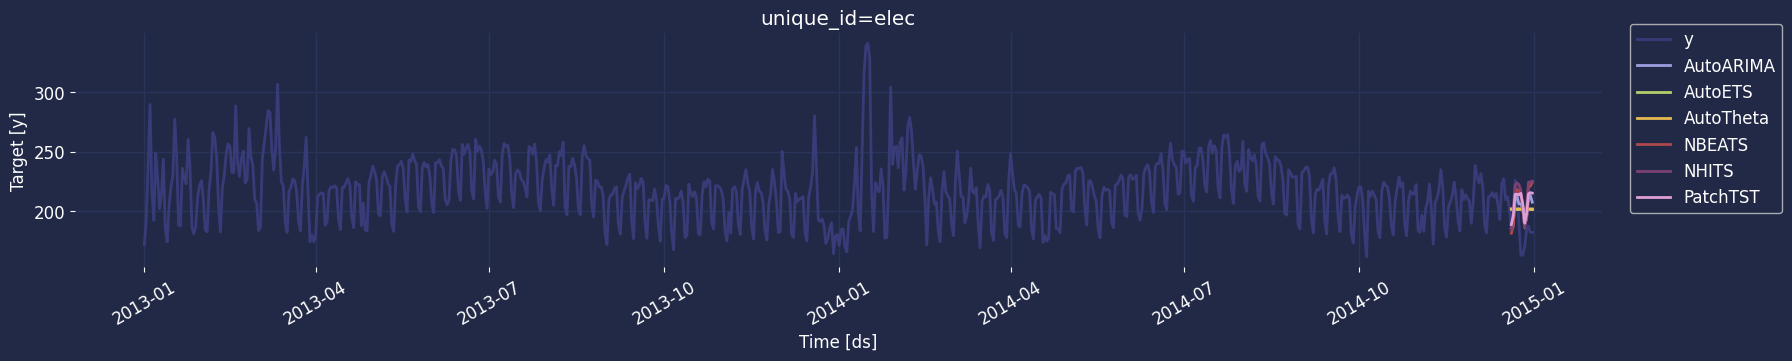

In [140]:
sf.plot(Y_train_df, fcst)
#sf.plot(Y_train_df, fcst, unique_ids=['Airline1'])

In [141]:
from functools import partial

import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

In [142]:
evals = evaluate(
    fcst,
    metrics=[ufl.mae, ufl.mape, partial(ufl.mase, seasonality=season_length), ufl.rmse, ufl.smape],
    train_df=Y_train_df,
).sort_values(by='unique_id')

evals

,unique_id,metric,AutoARIMA,AutoETS,AutoTheta,NBEATS,NHITS,PatchTST
0,elec,mae,19.843185,20.929458,20.960159,24.220823,24.885652,22.248954
1,elec,mape,0.111228,0.116365,0.116547,0.136125,0.140143,0.125782
2,elec,mase,0.713490,0.752549,0.753653,0.870894,0.894799,0.799993
3,elec,rmse,23.561297,23.406312,23.433317,29.070029,30.830437,27.112968
4,elec,smape,0.051751,0.054696,0.054772,0.062088,0.063159,0.057470


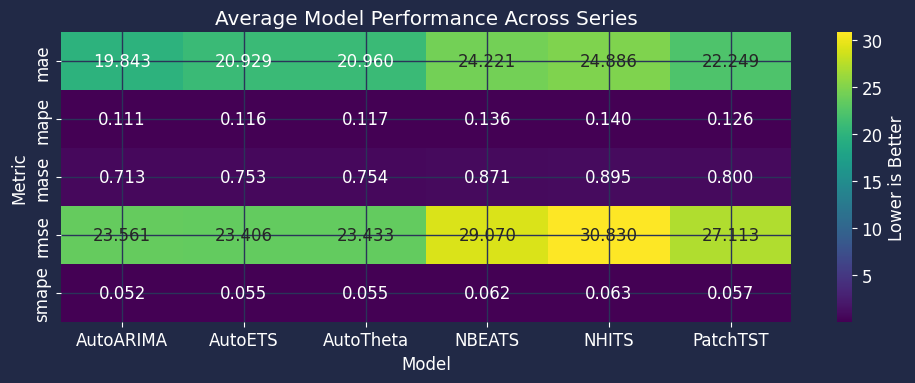

In [143]:
import seaborn as sns

df_avg = evals.groupby('metric')[model_names].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(df_avg, annot=True, fmt=".3f", cmap='viridis', cbar_kws={'label': 'Lower is Better'})
plt.title('Average Model Performance Across Series')
plt.ylabel('Metric')
plt.xlabel('Model')
plt.tight_layout()
plt.show()

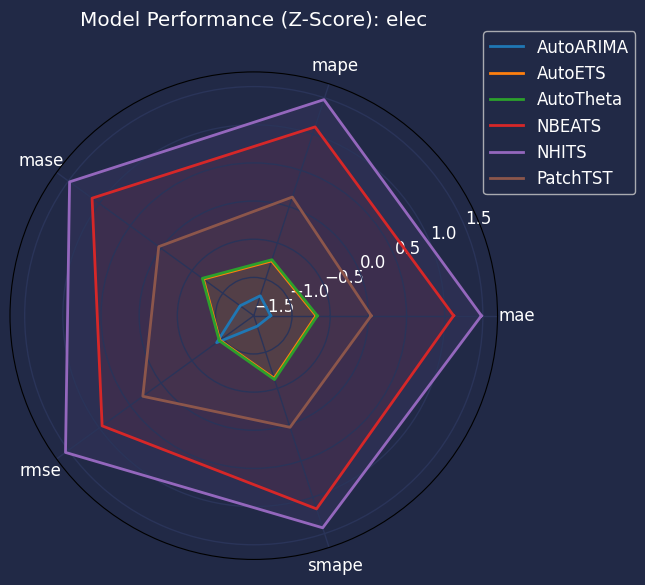

In [144]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 설정
unique_ids = evals['unique_id'].unique()
metrics = ['mae', 'mape', 'mase', 'rmse', 'smape']

n_series = len(unique_ids)
n_cols = len(unique_ids)
n_rows = int(np.ceil(n_series / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows), subplot_kw=dict(polar=True))

if n_series == 1:
    axes = np.array([axes])
elif isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = np.array([axes])

for idx, uid in enumerate(unique_ids):
    ax = axes[idx]

    df_series = evals[evals['unique_id'] == uid].set_index('metric').loc[metrics, model_names]

    # row-wise Z-score 정규화
    df_scaled = pd.DataFrame(index=metrics, columns=model_names, dtype=float)
    for metric in metrics:
        row = df_series.loc[metric]
        if row.isna().all():
            continue
        scaled_row = StandardScaler().fit_transform(row.dropna().values.reshape(-1, 1)).flatten()
        df_scaled.loc[metric, row.dropna().index] = scaled_row

    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    for model in model_names:
        if df_scaled[model].isna().any():
            continue
        values = df_scaled[model].tolist()
        values += values[:1]
        ax.plot(angles, values, label=model, linewidth=2)
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
    ax.set_title(f'Model Performance (Z-Score): {uid}', y=1.08)
    ax.grid(True)

# 범례 추가 (마지막 축 사용)
axes[min(len(axes)-1, n_series-1)].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 남은 축 비활성화
for ax in axes[len(unique_ids):]:
    ax.axis('off')

plt.tight_layout()
plt.show()
